# Find Programmatic way to isolate peaks

Approach
- filter to just 0 - 1200 seconds
- bin data along the AP axis and find median fluorescence in each bin
- smooth the florescence data
- use scipy.signal.find_peaks to identify peaks and troughs
- for each peak, find the distance to the nearest trough and use peak +/- that distance as the ap range of the peak (this centers the peak within the range)

In [71]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import math as math
import seaborn as sns 

In [72]:

data_filtered = pd.read_csv('../../data/Berrocal_2020/Data/eve_data_longform_w_nuclei_060520_FILTERED.csv', header=0)
print(data_filtered)

        Unnamed: 0  nucleus_id  particle_id  set_id    ap_raw  ap_registered  \
0              192      1.0517          NaN       1  0.417799       0.412853   
1              193      1.0517          NaN       1  0.415974       0.411356   
2              194      1.0517          NaN       1  0.414500       0.410133   
3              195      1.0517          NaN       1  0.414155       0.410011   
4              196      1.0517          NaN       1  0.414665       0.410521   
...            ...         ...          ...     ...       ...            ...   
430068      497451     11.1492          NaN      11  0.274391       0.290641   
430069      497452     11.1492          NaN      11  0.274822       0.291048   
430070      497453     11.1492          NaN      11  0.275375       0.291569   
430071      497454     11.1492          NaN      11  0.276047       0.292204   
430072      497455     11.1492          NaN      11  0.276220       0.292367   

              xPos        yPos  burst_s

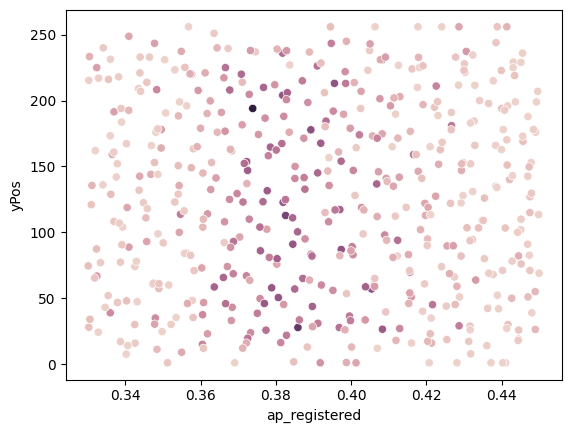

In [73]:
fluo_traces = data_filtered.pivot(index='nucleus_id', columns='time', values='fluo')
fluo_traces = fluo_traces.fillna(0)
fluo_traces.reset_index(inplace=True)

fluo_traces['sum_fluo'] = fluo_traces.iloc[:, 1:].sum(axis=1)

pos_data = data_filtered.drop(columns=['particle_id', 'set_id', 'ap_raw','burst_stripe_id', 'time', 'fluo',
       'inference_stripe_id', 'inference_fluo_id', 'v_state', 'v_fluo'])

# assign the nuclear position as the median position over the time window
pos_data = pos_data.groupby('nucleus_id').median()
pos_data.reset_index(inplace=True)

# filtering the nuclei for those in stripe 2 and the 1-2 and 2-3 interstripes
pos_data_str2 = pos_data[(pos_data['ap_registered']>0.33)& (pos_data['ap_registered']<0.45)]

pos_sum_df = fluo_traces.merge(pos_data_str2, on='nucleus_id')

sns.scatterplot(data=pos_sum_df, x="ap_registered", y="yPos", hue='sum_fluo', legend=False)
plt.show()
# sns.scatterplot(data=pos_sum_df, x="ap_registered", y="yPos", alpha=0.2, sizes=10, legend=False)
# plt.show()

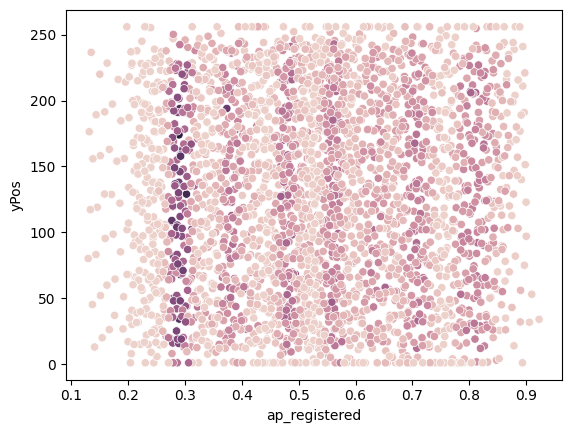

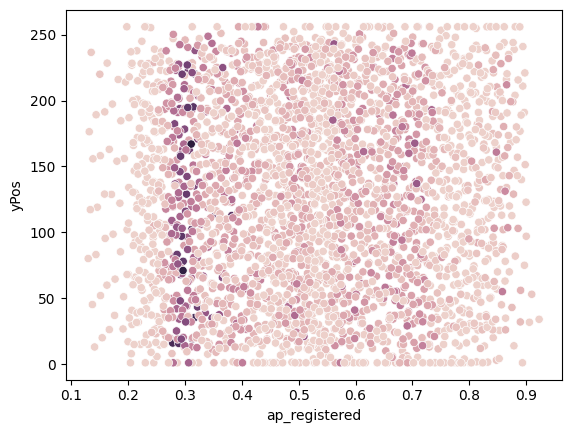

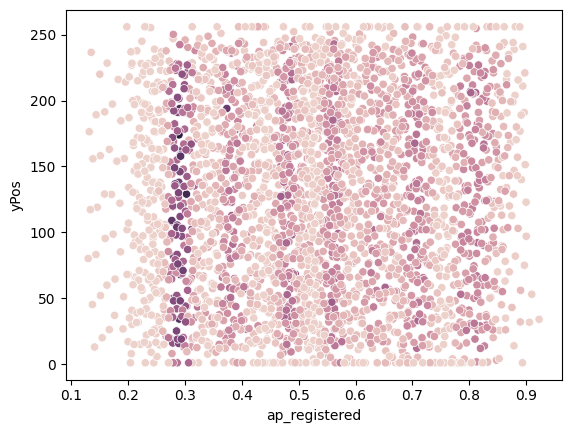

In [76]:
fluo_traces = data_filtered.pivot(index='nucleus_id', columns='time', values='fluo')
fluo_traces = fluo_traces.fillna(0)
fluo_traces.reset_index(inplace=True)

fluo_traces['sum_fluo'] = fluo_traces.iloc[:, 1:].sum(axis=1)
fluo_traces['sum_fluo_b41200'] = fluo_traces.iloc[:, 1:int(1200/20)+2].sum(axis=1)
fluo_traces['sum_fluo_after1200'] = fluo_traces.iloc[:, int(1200/20)+2:].sum(axis=1)

pos_data = data_filtered.drop(columns=['particle_id', 'set_id', 'ap_raw','burst_stripe_id', 'time', 'fluo',
       'inference_stripe_id', 'inference_fluo_id', 'v_state', 'v_fluo'])

# assign the nuclear position as the median position over the time window
pos_data = pos_data.groupby('nucleus_id').median()
pos_data.reset_index(inplace=True)

# filtering the nuclei for those in stripe 2 and the 1-2 and 2-3 interstripes
pos_data_str2 = pos_data#@[(pos_data['ap_registered']>0.33)& (pos_data['ap_registered']<0.45)]
pos_sum_df = fluo_traces.merge(pos_data_str2, on='nucleus_id')

sns.scatterplot(data=pos_sum_df, x="ap_registered", y="yPos", hue='sum_fluo', legend=False)
plt.show()
sns.scatterplot(data=pos_sum_df, x="ap_registered", y="yPos", hue='sum_fluo_b41200', legend=False)
plt.show()
sns.scatterplot(data=pos_sum_df, x="ap_registered", y="yPos", hue='sum_fluo_after1200', legend=False)
plt.show()

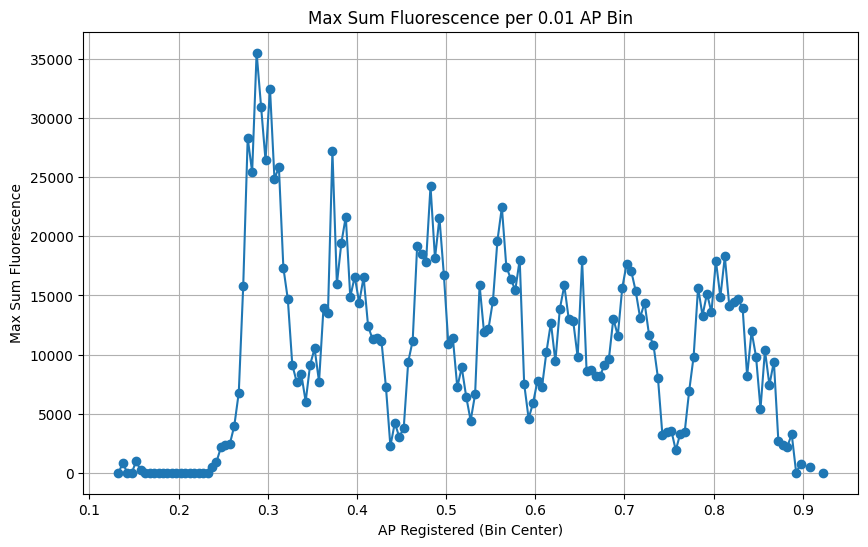

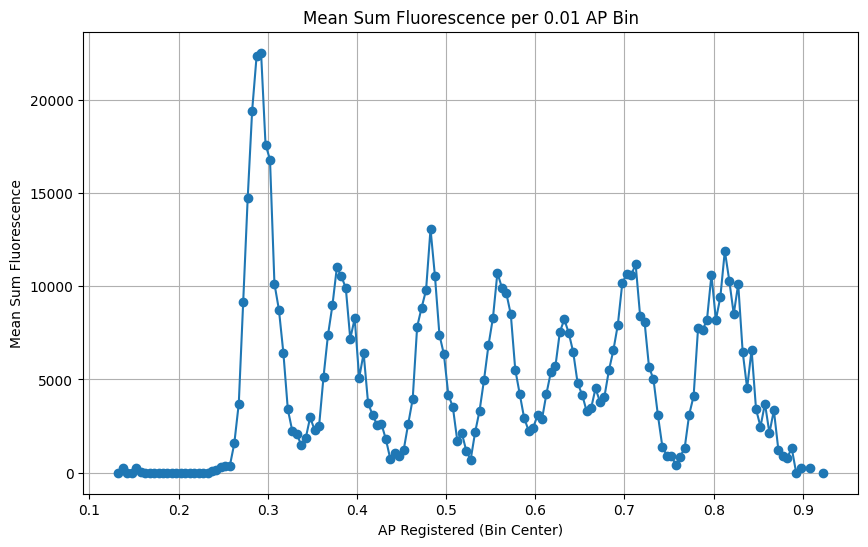

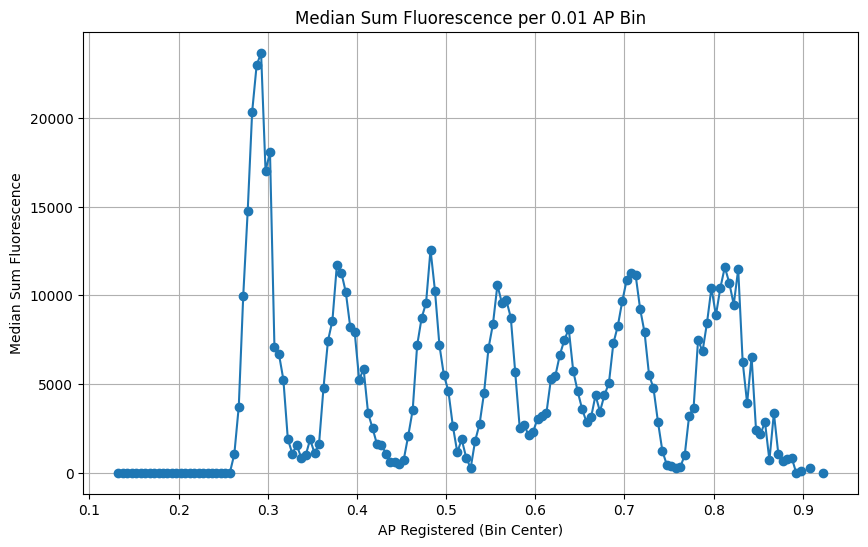

In [77]:
import numpy as np

# Define bin edges for ap_registered from min to max in steps of 0.01
min_ap = pos_sum_df['ap_registered'].min()
max_ap = pos_sum_df['ap_registered'].max()
BIN_SIZE = 0.005
bins = np.arange(min_ap, max_ap + BIN_SIZE, BIN_SIZE)

# Bin the data and find max sum_fluo per bin
pos_sum_df['ap_bin'] = pd.cut(pos_sum_df['ap_registered'], bins)
binned_max = pos_sum_df.groupby('ap_bin')['sum_fluo'].max().reset_index()

# Calculate bin centers for plotting
binned_max['ap_bin_center'] = binned_max['ap_bin'].apply(lambda x: x.mid)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(binned_max['ap_bin_center'], binned_max['sum_fluo'], marker='o', linestyle='-')
plt.xlabel('AP Registered (Bin Center)')
plt.ylabel('Max Sum Fluorescence')
plt.title('Max Sum Fluorescence per 0.01 AP Bin')
plt.grid(True)
plt.show()

# Bin the data and find mean sum_fluo per bin
pos_sum_df['ap_bin'] = pd.cut(pos_sum_df['ap_registered'], bins)
binned_mean = pos_sum_df.groupby('ap_bin')['sum_fluo'].mean().reset_index()

# Calculate bin centers for plotting
binned_mean['ap_bin_center'] = binned_mean['ap_bin'].apply(lambda x: x.mid)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(binned_mean['ap_bin_center'], binned_mean['sum_fluo'], marker='o', linestyle='-')
plt.xlabel('AP Registered (Bin Center)')
plt.ylabel('Mean Sum Fluorescence')
plt.title('Mean Sum Fluorescence per 0.01 AP Bin')
plt.grid(True)
plt.show()

# Bin the data and find mean sum_fluo per bin
pos_sum_df['ap_bin'] = pd.cut(pos_sum_df['ap_registered'], bins)
binned_median = pos_sum_df.groupby('ap_bin')['sum_fluo'].median().reset_index()

# Calculate bin centers for plotting
binned_median['ap_bin_center'] = binned_median['ap_bin'].apply(lambda x: x.mid)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(binned_median['ap_bin_center'], binned_median['sum_fluo'], marker='o', linestyle='-')
plt.xlabel('AP Registered (Bin Center)')
plt.ylabel('Median Sum Fluorescence')
plt.title('Median Sum Fluorescence per 0.01 AP Bin')
plt.grid(True)
plt.show()

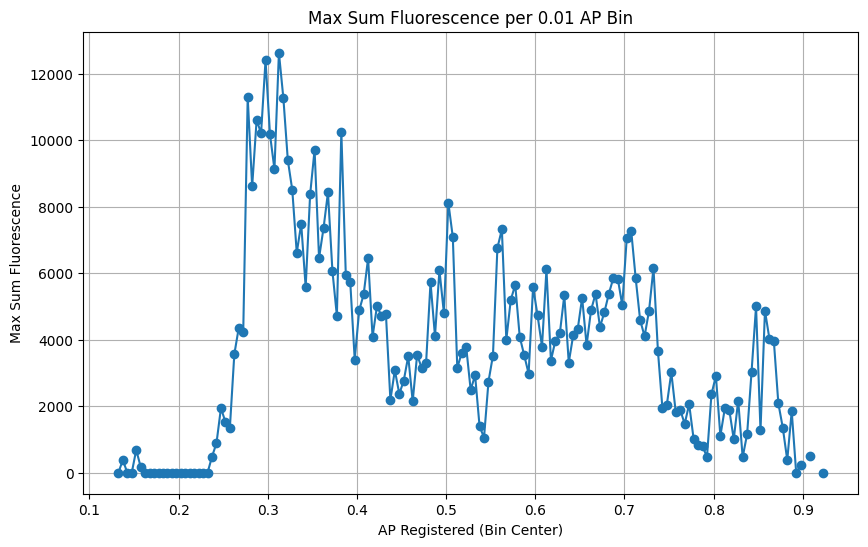

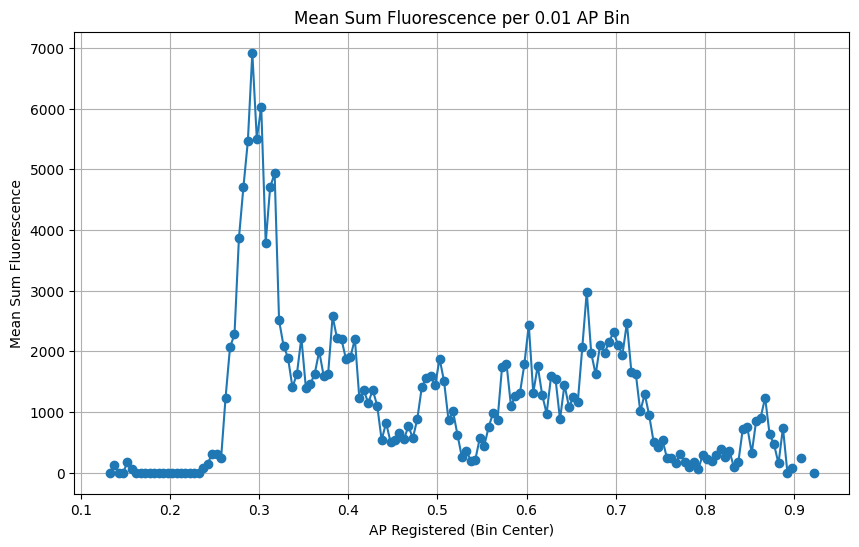

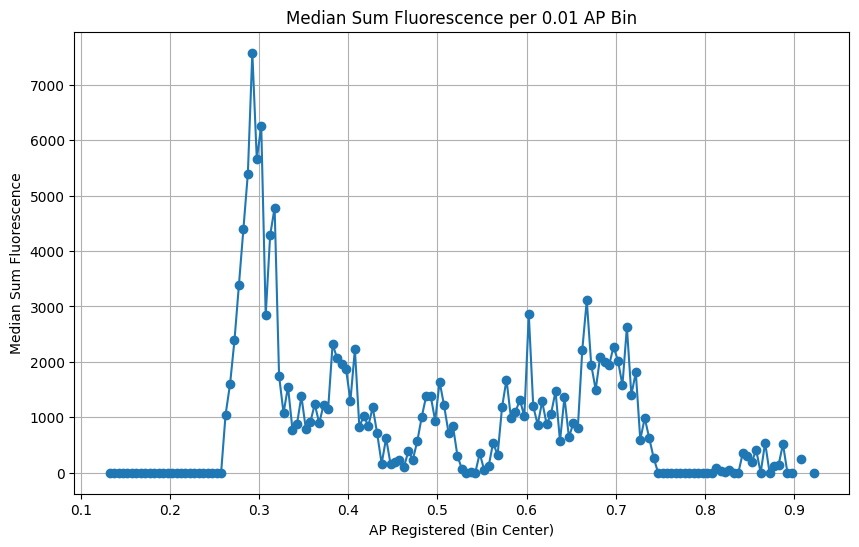

In [78]:
import numpy as np

# Define bin edges for ap_registered from min to max in steps of 0.01
min_ap = pos_sum_df['ap_registered'].min()
max_ap = pos_sum_df['ap_registered'].max()
BIN_SIZE = 0.005
bins = np.arange(min_ap, max_ap + BIN_SIZE, BIN_SIZE)

# Bin the data and find max sum_fluo per bin
pos_sum_df['ap_bin'] = pd.cut(pos_sum_df['ap_registered'], bins)
binned_max = pos_sum_df.groupby('ap_bin')['sum_fluo_b41200'].max().reset_index()

# Calculate bin centers for plotting
binned_max['ap_bin_center'] = binned_max['ap_bin'].apply(lambda x: x.mid)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(binned_max['ap_bin_center'], binned_max['sum_fluo_b41200'], marker='o', linestyle='-')
plt.xlabel('AP Registered (Bin Center)')
plt.ylabel('Max Sum Fluorescence')
plt.title('Max Sum Fluorescence per 0.01 AP Bin')
plt.grid(True)
plt.show()

# Bin the data and find mean sum_fluo per bin
pos_sum_df['ap_bin'] = pd.cut(pos_sum_df['ap_registered'], bins)
binned_mean = pos_sum_df.groupby('ap_bin')['sum_fluo_b41200'].mean().reset_index()

# Calculate bin centers for plotting
binned_mean['ap_bin_center'] = binned_mean['ap_bin'].apply(lambda x: x.mid)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(binned_mean['ap_bin_center'], binned_mean['sum_fluo_b41200'], marker='o', linestyle='-')
plt.xlabel('AP Registered (Bin Center)')
plt.ylabel('Mean Sum Fluorescence')
plt.title('Mean Sum Fluorescence per 0.01 AP Bin')
plt.grid(True)
plt.show()

# Bin the data and find mean sum_fluo per bin
pos_sum_df['ap_bin'] = pd.cut(pos_sum_df['ap_registered'], bins)
binned_median = pos_sum_df.groupby('ap_bin')['sum_fluo_b41200'].median().reset_index()

# Calculate bin centers for plotting
binned_median['ap_bin_center'] = binned_median['ap_bin'].apply(lambda x: x.mid)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(binned_median['ap_bin_center'], binned_median['sum_fluo_b41200'], marker='o', linestyle='-')
plt.xlabel('AP Registered (Bin Center)')
plt.ylabel('Median Sum Fluorescence')
plt.title('Median Sum Fluorescence per 0.01 AP Bin')
plt.grid(True)
plt.show()


Used moving average for smoothing.
Final smoothing method used: moving average (window=7)
Peak 1: AP range from 0.2575 to 0.3475, centered at 0.3025
Peak 2: AP range from 0.3475 to 0.4375, centered at 0.3925
Peak 3: AP range from 0.4525 to 0.5325, centered at 0.4925
Peak 4: AP range from 0.5375 to 0.6375, centered at 0.5875
Peak 5: AP range from 0.6375 to 0.7275, centered at 0.6825
Peak 6: AP range from 0.7925 to 0.9225, centered at 0.8575
Intel MKL ERROR: Parameter 6 was incorrect on entry to DGELSD.

Intel MKL ERROR: Parameter 6 was incorrect on entry to DGELSD.


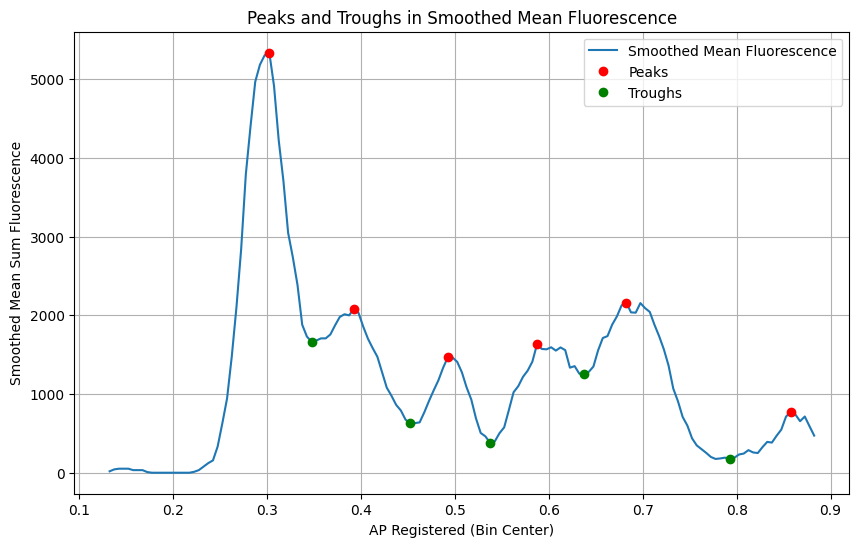

In [85]:
import scipy.signal as signal

# Assuming binned_mean is already defined from previous cells
# Smooth the mean fluorescence data using multiple methods for better peak detection
smoothed_fluo = None
# Assuming binned_mean is already defined from previous cells
# Smooth the mean fluorescence data using multiple methods for better peak detection
smoothed_fluo = None
smoothing_method = "none"

try:
    smoothed_fluo = signal.savgol_filter(binned_mean['sum_fluo_b41200'], window_length=11, polyorder=3)
    smoothing_method = "Savitzky-Golay (window=11, poly=3)"
    print("Used Savitzky-Golay filter for smoothing.")
except np.linalg.LinAlgError:
    try:
        # Try Savitzky-Golay with different parameters
        smoothed_fluo = signal.savgol_filter(binned_mean['sum_fluo_b41200'], window_length=9, polyorder=2)
        smoothing_method = "Savitzky-Golay (window=9, poly=2)"
        print("Used alternative Savitzky-Golay parameters for smoothing.")
    except np.linalg.LinAlgError:
        try:
            # Try a simple moving average
            window = 7
            smoothed_fluo = np.convolve(binned_mean['sum_fluo_b41200'], np.ones(window)/window, mode='same')
            smoothing_method = f"moving average (window={window})"
            print(f"Used moving average for smoothing.")
        except Exception:
            # Fallback to original data
            smoothed_fluo = binned_mean['sum_fluo_b41200'].values
            smoothing_method = "original data (smoothing failed)"
            print("Smoothing failed; using original data.")

print(f"Final smoothing method used: {smoothing_method}")

# Find peaks in the smoothed data
peaks, _ = signal.find_peaks(smoothed_fluo, prominence=300)  # Adjust prominence as needed

# Find troughs by inverting the data
troughs, _ = signal.find_peaks(-smoothed_fluo, prominence=300)

# For each peak, find the nearest troughs on left and right
ap_centers = binned_mean['ap_bin_center'].values
peak_ranges_closestTrough = []
peak_ranges_troughs = []
for peak_idx in peaks:
    peak_ap = ap_centers[peak_idx]
    # Find nearest left trough
    left_troughs = troughs[troughs < peak_idx]
    if len(left_troughs) > 0:
        left_trough_idx = left_troughs[-1]
        left_ap = ap_centers[left_trough_idx]
    else:
        left_ap = ap_centers[0]  # Start of data
    # Find nearest right trough
    right_troughs = troughs[troughs > peak_idx]
    if len(right_troughs) > 0:
        right_trough_idx = right_troughs[0]
        right_ap = ap_centers[right_trough_idx]
    else:
        right_ap = ap_centers[-1]  # End of data
    # Center the peak and cut off at troughs
    center_ap = peak_ap
    if center_ap - left_ap > right_ap - center_ap:
        left_cutoff = center_ap - (right_ap - center_ap)
        right_cutoff = right_ap
    else:
        right_cutoff = center_ap + (center_ap - left_ap)
        left_cutoff = left_ap

    peak_ranges_closestTrough.append((left_cutoff, center_ap, right_cutoff))
    peak_ranges_troughs.append((left_ap, center_ap, right_ap))

# Print the AP registered ranges for each peak
for i, (left, center, right) in enumerate(peak_ranges_closestTrough):
    print(f"Peak {i+1}: AP range from {left:.4f} to {right:.4f}, centered at {center:.4f}")

# Optional: Plot the smoothed data with peaks and troughs marked
plt.figure(figsize=(10, 6))
plt.plot(ap_centers, smoothed_fluo, label='Smoothed Mean Fluorescence')
plt.plot(ap_centers[peaks], smoothed_fluo[peaks], 'ro', label='Peaks')
plt.plot(ap_centers[troughs], smoothed_fluo[troughs], 'go', label='Troughs')
plt.xlabel('AP Registered (Bin Center)')
plt.ylabel('Smoothed Mean Sum Fluorescence')
plt.title('Peaks and Troughs in Smoothed Mean Fluorescence')
plt.legend()
plt.grid(True)
plt.show()


Intel MKL ERROR: Parameter 6 was incorrect on entry to DGELSD.
Used moving average for smoothing.
Final smoothing method used: moving average (window=5)
Peak 1: AP range from 0.2475 to 0.3375, centered at 0.2925
Peak 2: AP range from 0.3375 to 0.4275, centered at 0.3825
Peak 3: AP range from 0.4425 to 0.5225, centered at 0.4825
Peak 4: AP range from 0.5325 to 0.5925, centered at 0.5625
Peak 5: AP range from 0.6025 to 0.6625, centered at 0.6325
Peak 6: AP range from 0.6625 to 0.7525, centered at 0.7075
Peak 7: AP range from 0.7575 to 0.8775, centered at 0.8175

Intel MKL ERROR: Parameter 6 was incorrect on entry to DGELSD.


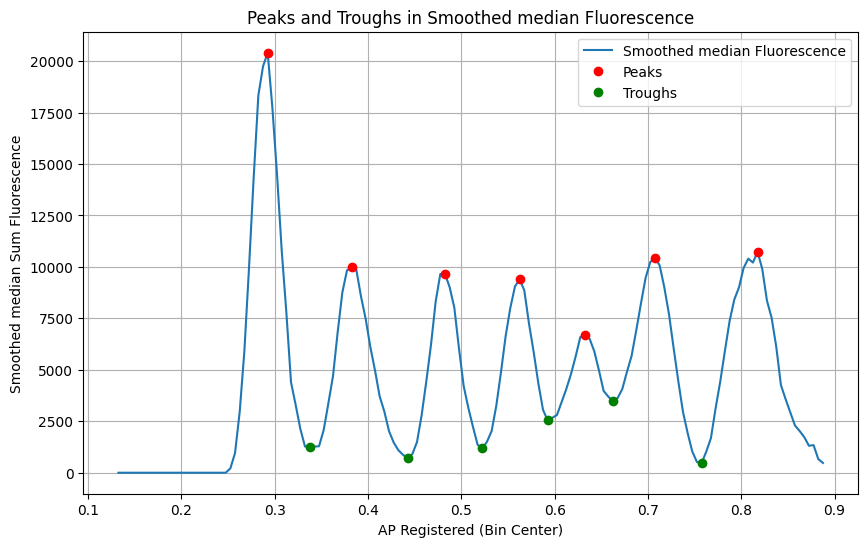

In [ ]:
import scipy.signal as signal

# Assuming binned_median is already defined from previous cells
# Smooth the median fluorescence data using multiple methods for better peak detection
smoothed_fluo = None
# Assuming binned_median is already defined from previous cells
# Smooth the median fluorescence data using multiple methods for better peak detection
smoothed_fluo = None
smoothing_method = "none"

try:
    smoothed_fluo = signal.savgol_filter(binned_median['sum_fluo'], window_length=11, polyorder=3)
    smoothing_method = "Savitzky-Golay (window=11, poly=3)"
    print("Used Savitzky-Golay filter for smoothing.")
except np.linalg.LinAlgError:
    try:
        # Try Savitzky-Golay with different parameters
        smoothed_fluo = signal.savgol_filter(binned_median['sum_fluo'], window_length=9, polyorder=2)
        smoothing_method = "Savitzky-Golay (window=9, poly=2)"
        print("Used alternative Savitzky-Golay parameters for smoothing.")
    except np.linalg.LinAlgError:
        try:
            # Try a simple moving average
            smoothed_fluo = np.convolve(binned_median['sum_fluo'], np.ones(5)/5, mode='same')
            smoothing_method = "moving average (window=5)"
            print("Used moving average for smoothing.")
        except Exception:
            # Fallback to original data
            smoothed_fluo = binned_median['sum_fluo'].values
            smoothing_method = "original data (smoothing failed)"
            print("Smoothing failed; using original data.")

print(f"Final smoothing method used: {smoothing_method}")

# Find peaks in the smoothed data
peaks, _ = signal.find_peaks(smoothed_fluo, prominence=1000)  # Adjust prominence as needed

# Find troughs by inverting the data
troughs, _ = signal.find_peaks(-smoothed_fluo, prominence=1000)

# For each peak, find the nearest troughs on left and right
ap_centers = binned_median['ap_bin_center'].values
peak_ranges_closestTrough = []
peak_ranges_troughs = []
for peak_idx in peaks:
    peak_ap = ap_centers[peak_idx]
    # Find nearest left trough
    left_troughs = troughs[troughs < peak_idx]
    if len(left_troughs) > 0:
        left_trough_idx = left_troughs[-1]
        left_ap = ap_centers[left_trough_idx]
    else:
        left_ap = ap_centers[0]  # Start of data
    # Find nearest right trough
    right_troughs = troughs[troughs > peak_idx]
    if len(right_troughs) > 0:
        right_trough_idx = right_troughs[0]
        right_ap = ap_centers[right_trough_idx]
    else:
        right_ap = ap_centers[-1]  # End of data
    # Center the peak and cut off at troughs
    center_ap = peak_ap
    if center_ap - left_ap > right_ap - center_ap:
        left_cutoff = center_ap - (right_ap - center_ap)
        right_cutoff = right_ap
    else:
        right_cutoff = center_ap + (center_ap - left_ap)
        left_cutoff = left_ap

    peak_ranges_closestTrough.append((left_cutoff, center_ap, right_cutoff))
    peak_ranges_troughs.append((left_ap, center_ap, right_ap))

# Print the AP registered ranges for each peak
for i, (left, center, right) in enumerate(peak_ranges_closestTrough):
    print(f"Peak {i+1}: AP range from {left:.4f} to {right:.4f}, centered at {center:.4f}")

# Optional: Plot the smoothed data with peaks and troughs marked
plt.figure(figsize=(10, 6))
plt.plot(ap_centers, smoothed_fluo, label='Smoothed median Fluorescence')
plt.plot(ap_centers[peaks], smoothed_fluo[peaks], 'ro', label='Peaks')
plt.plot(ap_centers[troughs], smoothed_fluo[troughs], 'go', label='Troughs')
plt.xlabel('AP Registered (Bin Center)')
plt.ylabel('Smoothed median Sum Fluorescence')
plt.title('Peaks and Troughs in Smoothed median Fluorescence')
plt.legend()
plt.grid(True)
plt.show()

<-Filtering for nuclei in peak 1 range: 0.2575 to 0.3475
Filtering for nuclei in peak 1 range: 0.1325 to 0.3475->


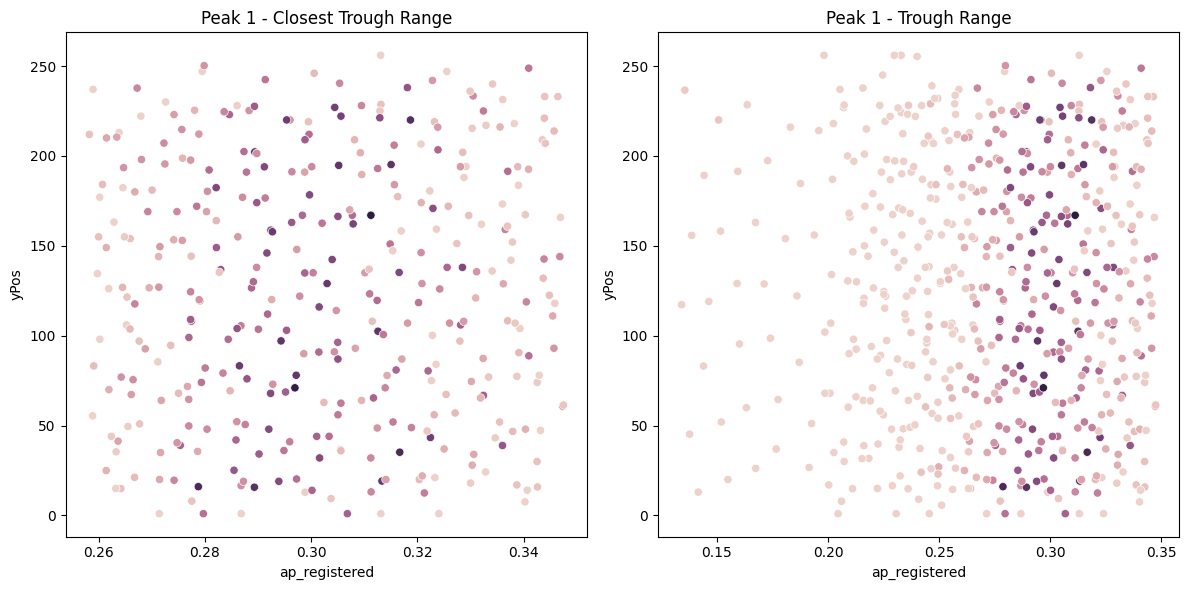

<-Filtering for nuclei in peak 2 range: 0.3475 to 0.43750000000000006
Filtering for nuclei in peak 2 range: 0.3475 to 0.4525->


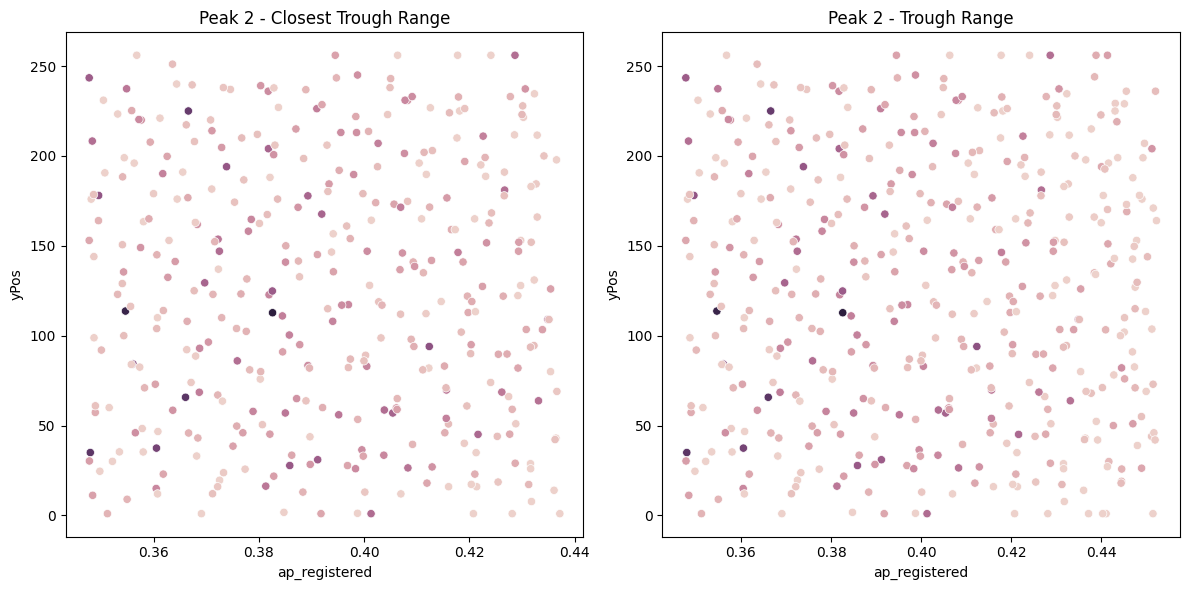

<-Filtering for nuclei in peak 3 range: 0.4525 to 0.5325
Filtering for nuclei in peak 3 range: 0.4525 to 0.5375000000000001->


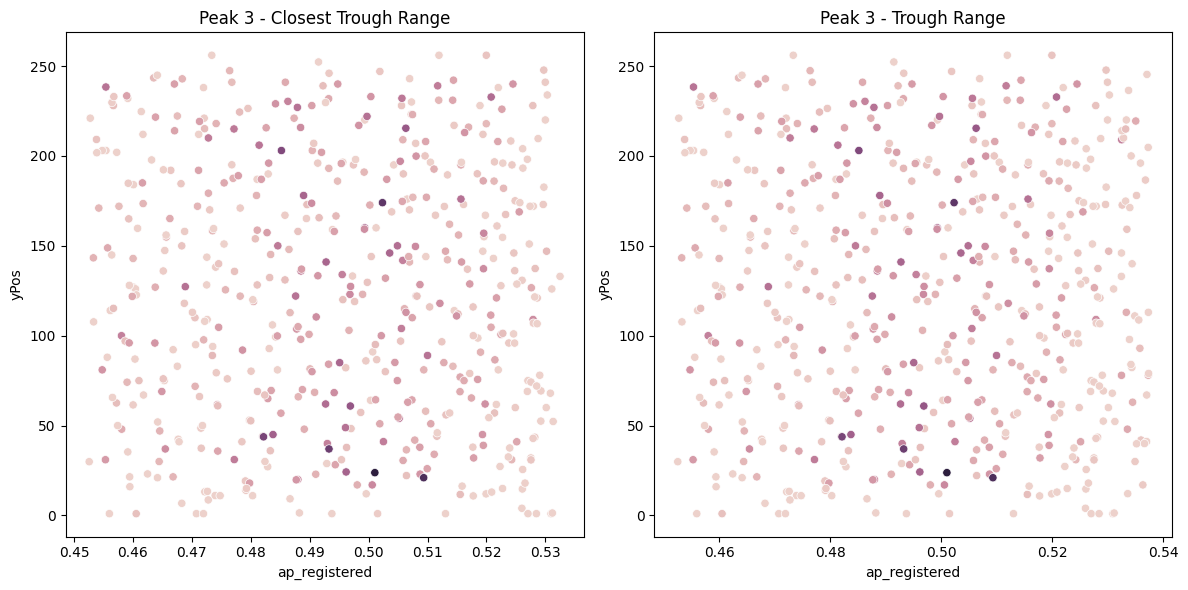

<-Filtering for nuclei in peak 4 range: 0.5375000000000001 to 0.6374999999999997
Filtering for nuclei in peak 4 range: 0.5375000000000001 to 0.6375->


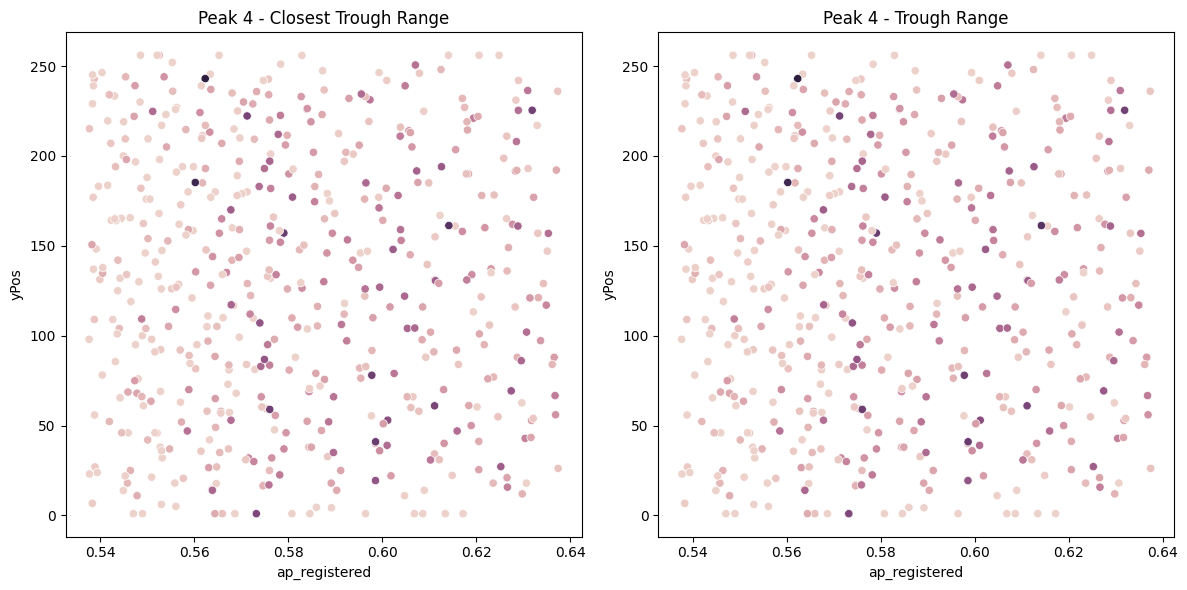

<-Filtering for nuclei in peak 5 range: 0.6375 to 0.7275000000000003
Filtering for nuclei in peak 5 range: 0.6375 to 0.7925->


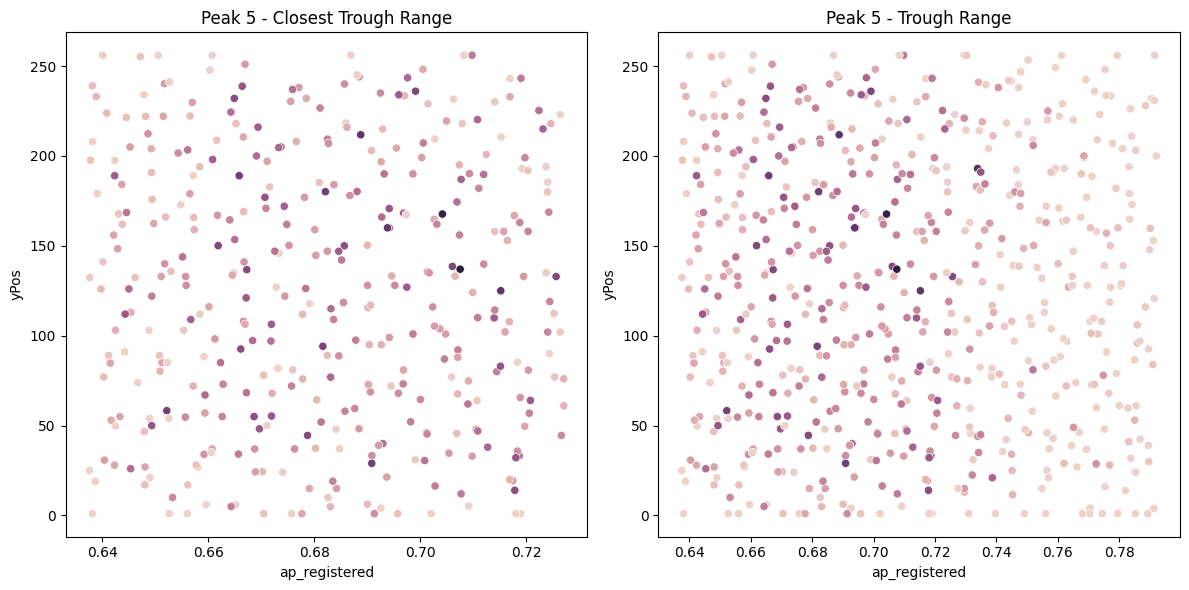

<-Filtering for nuclei in peak 6 range: 0.7925 to 0.9224999999999999
Filtering for nuclei in peak 6 range: 0.7925 to 0.9225000000000001->


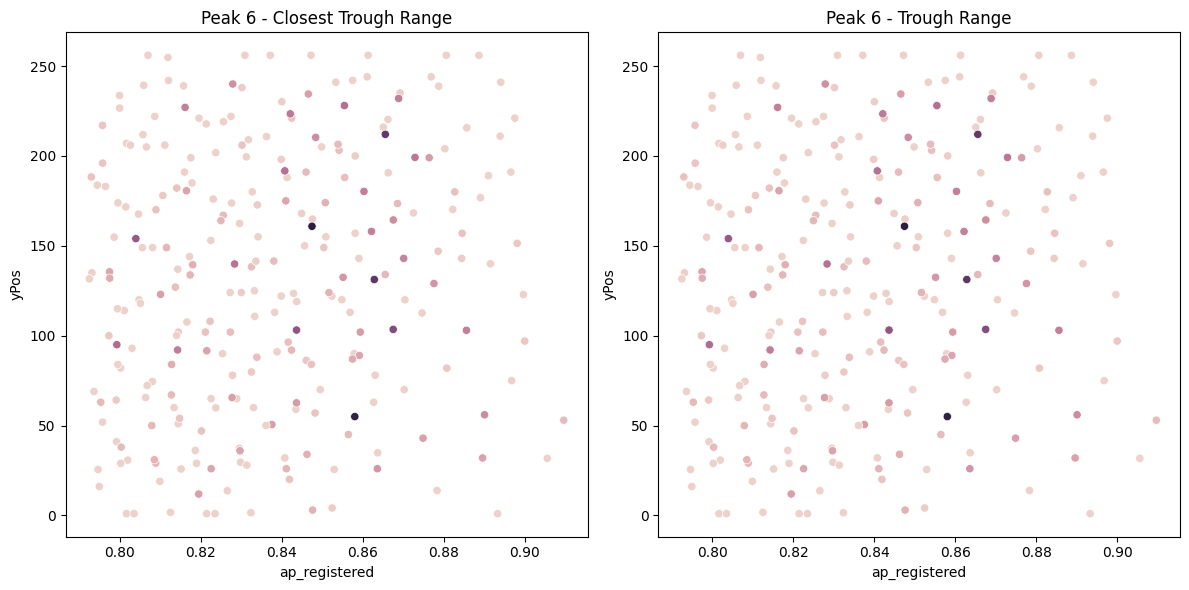

In [80]:
for i in range(len(peak_ranges_closestTrough)):
    print(f"<-Filtering for nuclei in peak {i+1} range: {peak_ranges_closestTrough[i][0]} to {peak_ranges_closestTrough[i][2]}")
    print(f"Filtering for nuclei in peak {i+1} range: {peak_ranges_troughs[i][0]} to {peak_ranges_troughs[i][2]}->")
    # filtering the nuclei for those in stripe 2
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    pos_data_str2 = pos_data[(pos_data['ap_registered']>peak_ranges_closestTrough[i][0])& (pos_data['ap_registered']<peak_ranges_closestTrough[i][2])]
    pos_sum_df = fluo_traces.merge(pos_data_str2, on='nucleus_id')
    sns.scatterplot(data=pos_sum_df, x="ap_registered", y="yPos", hue='sum_fluo_b41200', legend=False, ax=axes[0])
    axes[0].set_title(f'Peak {i+1} - Closest Trough Range')
    
    pos_data_str2 = pos_data[(pos_data['ap_registered']>peak_ranges_troughs[i][0])& (pos_data['ap_registered']<peak_ranges_troughs[i][2])]
    pos_sum_df = fluo_traces.merge(pos_data_str2, on='nucleus_id')
    sns.scatterplot(data=pos_sum_df, x="ap_registered", y="yPos", hue='sum_fluo_b41200', legend=False, ax=axes[1])
    axes[1].set_title(f'Peak {i+1} - Trough Range')
    
    plt.tight_layout()
    plt.show()